<a href="https://colab.research.google.com/github/antoniocluevanos/MySdeSM/blob/main/PIA_MySdeSM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# -----------------------------------------------------------------
# 1. Definición de la Ecuación Dinámica (Equivalente a cap5_robot2gdl.m)
# -----------------------------------------------------------------

def f(t, x):
    # 1. Vector de Estados (Entrada)
    q1  = x[0]
    q2  = x[1]
    qp1 = x[2]
    qp2 = x[3]

    q  = np.array([q1, q2])
    qp = np.array([qp1, qp2])

    # 2. Matriz de Inercia M(q)  (Ec. 5.43, valores numéricos pág. 283)
    M = np.array([
        [3.117 + 0.2 * np.cos(q2),  0.108 + 0.1 * np.cos(q2)],
        [0.108 + 0.1 * np.cos(q2),  0.108]
    ])

    # 3. Matriz de fuerzas centrípetas y de Coriolis C(q, qp)  (pág. 283)
    C = np.array([
        [-0.2 * np.sin(q2) * qp2,  -0.1 * np.sin(q2) * qp2],
        [ 0.1 * np.sin(q2) * qp1,   0.0]
    ])

    # 4. Vector de pares gravitacionales g(q)  (pág. 284)
    g = np.array([
        39.3 * np.sin(q1) + 1.95 * np.sin(q1 + q2),
        1.95 * np.sin(q1 + q2)
    ])

    # 5. Vector de fricción f(qp)  (viscosa + Coulomb, pág. 284)
    fr = np.array([
        1.86 * qp1 + 1.93 * np.tanh(100000 * qp1),
        0.16 * qp2 + 0.3  * np.tanh(100000 * qp2)
    ])

    # 6. Par de entrada (motores), Ecuación (5.44) del libro
    tau_t = tau(t)

    # 7. Cálculo de la aceleración articular:
    qpp = np.linalg.solve(M, tau_t - C @ qp - g - fr)

    # 8. Vector de salida (derivada del estado)
    dxdt = [qp1, qp2, qpp[0], qpp[1]]

    return dxdt


# --- Función de Par de Entrada ---
def tau(t):
    tau1 = (1 - np.exp(-0.8 * t)) * 32.0 + 56 * np.sin(16 * t + 0.1) + 12 * np.sin(20 * t + 0.15)
    tau2 = (1 - np.exp(-1.8 * t)) * 1.2 + 8 * np.sin(26 * t + 0.08) + 2 * np.sin(12 * t + 0.34)
    return np.array([tau1, tau2])



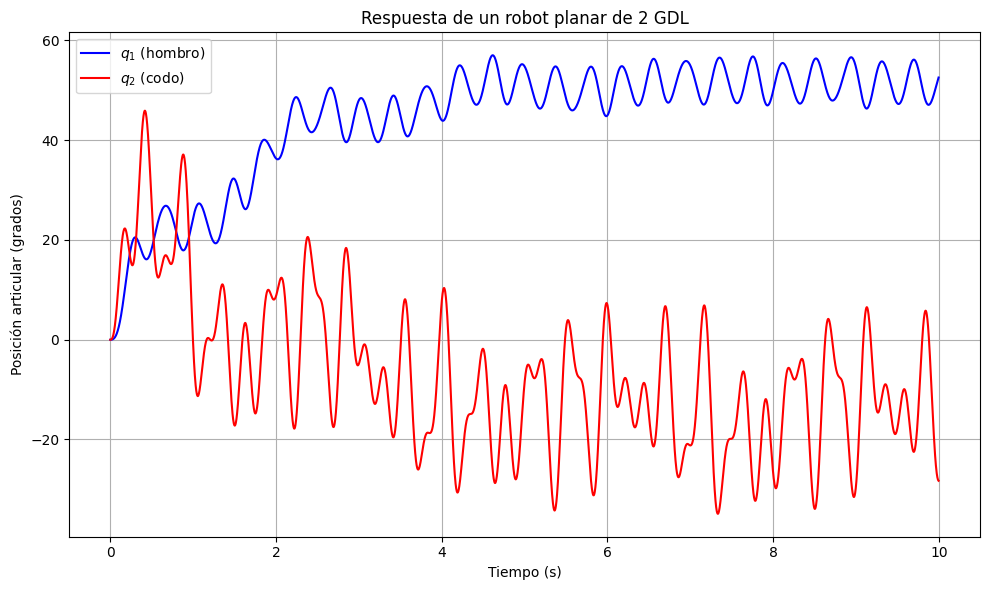

In [17]:

# -----------------------------------------------------------------
# 2. Script Principal de Simulación (Equivalente a cap5_simurobot2gdl.m)
# -----------------------------------------------------------------

# 1. Parámetros de Simulación
ti = 0.0
tf = 10.0
h = 0.0025

# Vector de tiempo para la evaluación
ts = np.arange(ti, tf, h)

# 2. Condiciones Iniciales
q1_0, q2_0 = 0.0, 0.0
qp1_0, qp2_0 = 0.0, 0.0
x0 = [q1_0, q2_0, qp1_0, qp2_0]

# 3. Resolución de la Ecuación Diferencial
sol = solve_ivp(f, [ti, tf], x0, t_eval=ts, rtol=1e-3,
first_step=2.5e-3, max_step=2.5e-3)

t = sol.t
q1 = sol.y[0]
q2 = sol.y[1]
qp1 = sol.y[2]
qp2 = sol.y[3]

# 4. Procesamiento y Gráficas de Resultados
q1_grados = np.rad2deg(q1)
q2_grados = np.rad2deg(q2)

plt.figure(figsize=(10, 6))
plt.plot(t, q1_grados, 'b-', label=r'$q_1$ (hombro)')
plt.plot(t, q2_grados, 'r-', label=r'$q_2$ (codo)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Posición articular (grados)')
plt.title('Respuesta de un robot planar de 2 GDL')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('respuesta_robot_2gdl.png', dpi=150)
plt.show()